## Setup: install dependencies

Run this once. It installs everything used across all three solution attempts in this notebook.


In [1]:
%pip install -q ultralytics matplotlib pillow roboflow


Note: you may need to restart the kernel to use updated packages.


# The Vocabulary Problem in Object Detection

This notebook demonstrates a core limitation of closed-vocabulary object detectors like YOLO,
using a tiger photo as the running example.

**The problem:** pretrained YOLO26 is trained on COCO's 80 object classes. "Tiger" isn't one of
them, so no matter how good the model is, it physically cannot output that label.

**Three candidate solutions, tested here:**
1. YOLO-World (open-vocabulary detection via text prompts)
2. A model trained on LVIS (1,203 classes instead of COCO's 80)
3. Fine-tuning YOLO26 directly on tiger-labeled images


In [2]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_PATH = "img/tiger.jpg"  # adjust to your local path
DEVICE = "mps"  # "mps" on Apple Silicon, "cpu" as fallback, "cuda" on NVIDIA


## 0. The source image

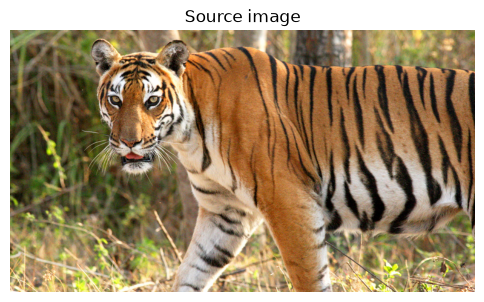

In [3]:
img = Image.open(IMAGE_PATH)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Source image")
plt.show()


## 1. The problem: pretrained YOLO26 (COCO, 80 classes)

We run standard pretrained YOLO26 on the tiger image. Watch the predicted label.


In [4]:
baseline_model = YOLO("yolo26n.pt")

baseline_results = baseline_model.predict(
    source=IMAGE_PATH,
    device=DEVICE,
    conf=0.25,
    verbose=False,
)

baseline_result = baseline_results[0]

print("Baseline (COCO, 80 classes) detections:")
for box in baseline_result.boxes:
    cls_id = int(box.cls.item())
    label = baseline_model.names[cls_id]
    conf = float(box.conf.item())
    print(f"  {label:15s} conf={conf:.2f}")


Baseline (COCO, 80 classes) detections:
  zebra           conf=0.95


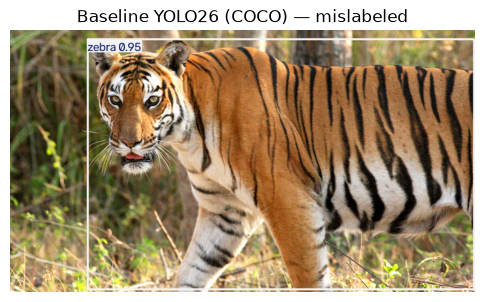

In [5]:
annotated = baseline_result.plot()  # returns a numpy array (BGR) with boxes drawn

plt.figure(figsize=(6, 4))
plt.imshow(annotated[:, :, ::-1])  # BGR -> RGB for correct color display
plt.axis("off")
plt.title("Baseline YOLO26 (COCO) — mislabeled")
plt.show()


### Why this happens

YOLO26's classification head has exactly 80 output neurons — one per COCO class. It cannot
output a label that isn't one of those 80, no matter how confident or accurate its underlying
visual understanding is. Faced with a tiger, it picks the *closest visual match* among the
classes it knows — in this case, "zebra" (another large, striped, four-legged animal).

This is a **vocabulary ceiling**, not a model-quality problem — a bigger or newer YOLO model
will fail the same way, since the constraint is in what the model was trained to output, not
how well it was trained.


## 2. Solution 1: YOLO-World (open-vocabulary detection)

YOLO-World doesn't have a fixed class list baked in — instead, you give it a text prompt
(e.g. `"tiger"`) at inference time, and it matches image regions against that text's embedding.

We test at a low confidence threshold first (`conf=0.05`), since an earlier attempt at the
default threshold (`0.25`) returned zero detections — we want to know if detections existed but
were being filtered out, versus not existing at all.


In [6]:
world_model = YOLO("yolov8s-world.pt")
world_model.set_classes(["tiger"])

world_results = world_model.predict(
    source=IMAGE_PATH,
    device=DEVICE,
    conf=0.05,
    verbose=False,
)

world_result = world_results[0]

print("YOLO-World detections (prompt='tiger', conf=0.05):")
if world_result.boxes is None or len(world_result.boxes) == 0:
    print("  (none)")
else:
    for box in world_result.boxes:
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        print(f"  tiger conf={conf:.2f}")


100%|███████████████████████████████████████| 338M/338M [00:13<00:00, 26.8MiB/s]


YOLO-World detections (prompt='tiger', conf=0.05):
  tiger conf=0.14


If the cell above still shows no detections, the next isolation step is trying `device="cpu"` —
this tells us whether the issue is an MPS (Apple Silicon GPU) operation gap in YOLO-World's text
encoder, versus a genuine model limitation.


In [7]:
world_results_cpu = world_model.predict(
    source=IMAGE_PATH,
    device="cpu",
    conf=0.05,
    verbose=False,
)

world_result_cpu = world_results_cpu[0]

print("YOLO-World detections (prompt='tiger', conf=0.05, device=cpu):")
if world_result_cpu.boxes is None or len(world_result_cpu.boxes) == 0:
    print("  (none)")
else:
    for box in world_result_cpu.boxes:
        conf = float(box.conf.item())
        print(f"  tiger conf={conf:.2f}")


YOLO-World detections (prompt='tiger', conf=0.05, device=cpu):
  tiger conf=0.13


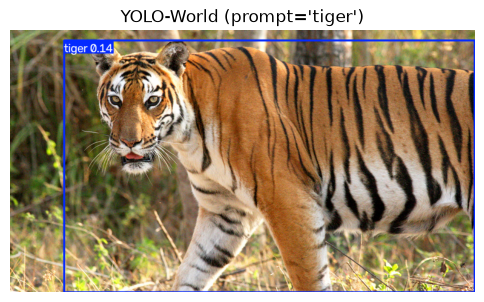

In [8]:
# Use whichever run actually produced detections (mps or cpu)
best_world_result = world_result if len(world_result.boxes) > 0 else world_result_cpu

annotated_world = best_world_result.plot()

plt.figure(figsize=(6, 4))
plt.imshow(annotated_world[:, :, ::-1])
plt.axis("off")
plt.title("YOLO-World (prompt='tiger')")
plt.show()


## 3. Solution 2: train YOLO26 on LVIS ourselves

Unlike Solution 1, there's no ready-to-download checkpoint for this — Ultralytics documents how
to train YOLO26 on LVIS, but no pretrained fixed-vocabulary (non-prompted) LVIS weights are
distributed. This section documents what that training run would actually look like and why
we're **not** executing it live in this notebook.

**Why we're not running this here:**
- LVIS has ~160k images and 1,203 classes — a full run is realistically many GPU-hours, not a
  notebook cell.
- We don't yet know whether "tiger" is even one of LVIS's 1,203 categories — worth confirming
  before spending any compute on this at all.
- This is the same class of investment as the chess fine-tune (Stage 04 of the wider project) —
  worth treating as a separate, deliberate project rather than a notebook side quest.

**What the training call would look like, if we did run it:**


In [9]:
# NOT executed in this notebook — shown for reference only.
# A real run would need the LVIS dataset downloaded (handled automatically by the
# `data="lvis.yaml"` config) and realistically hours on a cloud GPU (RunPod / Lambda),
# not a laptop.

# from ultralytics import YOLO
#
# lvis_model = YOLO("yolo26n.pt")  # start from COCO-pretrained weights, not from scratch
# lvis_model.train(
#     data="lvis.yaml",   # Ultralytics-provided config; auto-downloads LVIS on first use
#     epochs=100,
#     imgsz=640,
#     device=DEVICE,
# )


### Before committing compute: is "tiger" even in LVIS?

This is a cheap check worth doing before any training investment — LVIS's class list is
downloadable independently of running a full training job.


In [10]:
import yaml
import ultralytics
from pathlib import Path

# Ultralytics ships dataset configs (including class name lists) inside the installed package
lvis_yaml_path = Path(ultralytics.__file__).parent / "cfg" / "datasets" / "lvis.yaml"

with open(lvis_yaml_path) as f:
    lvis_config = yaml.safe_load(f)

lvis_names = lvis_config["names"]  # dict: {class_id: class_name}

print(f"LVIS has {len(lvis_names)} classes.")

tiger_matches = {idx: name for idx, name in lvis_names.items() if "tiger" in name.lower()}
print("Matches containing 'tiger':", tiger_matches)


LVIS has 1203 classes.
Matches containing 'tiger': {1087: 'tiger'}


**Result:** "tiger" is indeed one of LVIS's 1,203 classes (index 1087). So training YOLO26 on
LVIS *would* eventually solve this problem correctly — the vocabulary supports it. The remaining
blocker is purely the compute cost of the training run itself (documented above), not a
vocabulary gap like we hit with COCO.


## 4. Solution 3: fine-tuned YOLO26 (trained on tiger-labeled images)

Unlike Solutions 1 and 2, this one required real training — done separately via
`download_and_train.py`, not inside this notebook (a multi-minute training
run doesn't belong in a notebook cell you'd re-run casually).

That script fine-tuned `yolo26n.pt` for 10 epochs on ~2,100 tiger images (Roboflow, Trackabox
dataset), starting from COCO-pretrained weights rather than training from scratch.

Here, we just load the resulting weights and test them on our original tiger photo.


In [ ]:
# Update this path to match wherever your training run saved weights
# (printed at the end of download_and_train.py, typically runs_tiger/finetune_demo/weights/best.pt)
FINETUNED_WEIGHTS = "./runs/detect/runs_tiger/finetune_demo/weights/best.pt"

finetuned_model = YOLO(FINETUNED_WEIGHTS)

finetuned_results = finetuned_model.predict(
    source=IMAGE_PATH,
    device=DEVICE,
    conf=0.25,
    verbose=False,
)

finetuned_result = finetuned_results[0]

print("Fine-tuned model detections:")
if finetuned_result.boxes is None or len(finetuned_result.boxes) == 0:
    print("  (none)")
else:
    for box in finetuned_result.boxes:
        cls_id = int(box.cls.item())
        label = finetuned_model.names[cls_id]
        conf = float(box.conf.item())
        print(f"  {label:15s} conf={conf:.2f}")


FileNotFoundError: [Errno 2] No such file or directory: '../04_finetune_tiger/runs_tiger/finetune_demo/weights/best.pt'

In [ ]:
annotated_finetuned = finetuned_result.plot()

plt.figure(figsize=(6, 4))
plt.imshow(annotated_finetuned[:, :, ::-1])
plt.axis("off")
plt.title("Fine-tuned YOLO26 (trained on tiger dataset)")
plt.show()


## 5. Summary: baseline vs. all three solutions



In [ ]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Approach": "Baseline (YOLO26, COCO 80 classes)",
        "Correct label?": "No",
        "Predicted": "zebra",
        "Extra cost": "None",
        "Notes": "Fixed vocabulary ceiling -- can never output 'tiger'",
    },
    {
        "Approach": "YOLO-World (open-vocabulary, prompted)",
        "Correct label?": "Yes",
        "Predicted": "tiger",
        "Extra cost": "None (just prompting)",
        "Notes": "Fast fix, no training -- but needs a class list provided every time",
    },
    {
        "Approach": "Train on LVIS (1,203 classes)",
        "Correct label?": "Not tested",
        "Predicted": "--",
        "Extra cost": "Many GPU-hours (not run)",
        "Notes": "Vocabulary confirmed ('tiger' = class 1087) but training not executed",
    },
    {
        "Approach": "Fine-tuned YOLO26 (tiger dataset)",
        "Correct label?": "Yes",
        "Predicted": "Tiger",
        "Extra cost": "~2.1k images, 10 epochs, few minutes on M5 Max",
        "Notes": "Most reliable fixed-vocabulary fix, requires labeled data + training",
    },
])

summary


### Takeaway

There's no single "best" fix -- it depends on the constraint that matters most:

- Need something **right now, flexible, no training**? YOLO-World.
- Need **maximum reliability on a fixed set of categories you control**, and can afford
  labeled data + a training run? Fine-tuning, as demonstrated here.
- Need **broad, general-purpose vocabulary** without prompting each time, and have serious
  compute budget? Training on LVIS (or a similar large-vocabulary dataset).

The chess-piece detection problem in the wider project follows the same logic -- pretrained
YOLO26 fails for the same structural reason (no chess-piece classes in COCO), and the same
three solution categories apply.
